# Shapers

In [23]:
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
import tdspy as tds
import tdspy.plot as tdsplot
import cvxpy as cp

## Zero-vibration (ZV) shaper


$$
S(s) = A + (1 - A) * e^{(-sT)}
$$

In [24]:
def zv_shaper(s0: complex):
    """ S(s) = A + (1 - A) * exp(-s*T)
    Args:
        c0 (complex): zero to place
    """

    beta, omega = -np.real(s0), np.abs(np.imag(s0))
    T = np.pi / omega
    A = np.exp(np.pi*beta/omega) / (1 + np.exp(np.pi*beta/omega))

    # also equivalent to
    tau_vector = np.array([0.0, T], dtype=np.float64)
    a_vector = np.array([A, 1-A], dtype=np.float64)
    return tau_vector, a_vector


def dazv_shaper(s0: complex, alpha=0.3, T=None):
    """
                    1             exp(-s*alpha*T) - exp(-s*T)
    S(s) =  ----------------- * -------------------------------
             (1 - alpha) * T                  s
    """
    assert alpha >= 0.0 and alpha <= 1.0
    
    beta, omega = -np.real(s0), np.abs(np.imag(s0))
    if T is None:
        T = 0.5 * np.pi / omega
    
    assert T >= 0 and T<= np.pi / omega

    # code logic here
    raise NotImplementedError("...")


def residual_vibrations(s, a_vector, tau_vector):
    pass


In [25]:
s0 = -24*0.1 + 24*np.sqrt(1-0.1**2)*1j
tau_vector, a_vector = zv_shaper(s0=s0)

E = np.zeros(shape=(0,0), dtype=np.float64)
A = np.zeros(shape=(0,0,0), dtype=np.float64)
hA = np.zeros(shape=(0,), dtype=np.float64)

B = np.zeros(shape=(0,2,0), dtype=np.float64)
hB = np.array([], dtype=np.float64)

C = np.zeros(shape=(1,0,0), dtype=np.float64)
hC = np.zeros(shape=(0,), dtype=np.float64)

D = a_vector[np.newaxis, np.newaxis, :]
hD = tau_vector

ddae = tds.DDAE(A, hA, E=E, B=B, hB=hB, C=C, hC=hC, D=D, hD=hD)

In [26]:
zeros, _ = tds.zeros(ddae, r=[-100, 10, 0, 1250])
print(zeros)

[-2.4  +23.87969849j -2.4  +71.63909547j -2.4+1217.86462302j
 -2.4 +119.39849245j -2.4 +167.15788943j -2.4 +214.91728642j
 -2.4+1170.10522604j -2.4 +262.6766834j  -2.4 +310.43608038j
 -2.4+1122.34582906j -2.4 +358.19547736j -2.4 +405.95487434j
 -2.4+1074.58643208j -2.4 +453.71427132j -2.4 +501.4736683j
 -2.4 +549.23306528j -2.4 +596.99246226j -2.4+1026.82703509j
 -2.4 +644.75185925j -2.4 +979.06763811j -2.4 +692.51125623j
 -2.4 +931.30824113j -2.4 +740.27065321j -2.4 +883.54884415j
 -2.4 +788.03005019j -2.4 +835.78944717j]


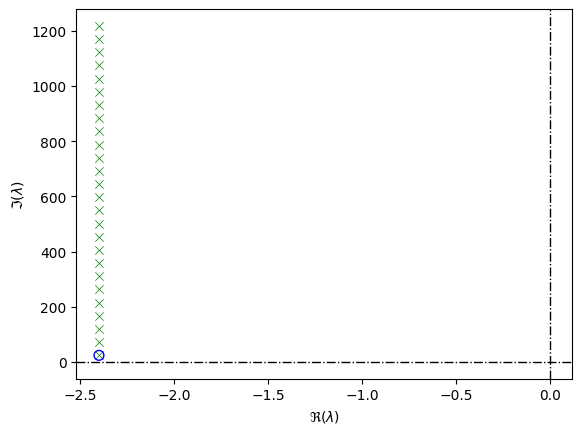

In [27]:
tdsplot.eigen_plot(zeros)
plt.scatter([np.real(s0)], [np.imag(s0)], s=50, facecolors='none', edgecolors='b', marker="o")
#plt.plot([np.real(placed_zero)],[np.imag([placed_zero])], "ro", alpha=0.4)

In [28]:
real_points = np.linspace(-5, 0,  num=100)
imag_points = np.linspace(0, 50, num=100)
real_grid, imag_grid = np.meshgrid(real_points, imag_points)
complex_array = real_grid + imag_grid * 1j

In [29]:
complex_array.shape

(100, 100)

In [30]:
r = np.abs(
    np.sum(
        np.exp(complex_array[:,:,np.newaxis] * tau_vector[np.newaxis,:]) * a_vector,
        axis=-1
    )
)

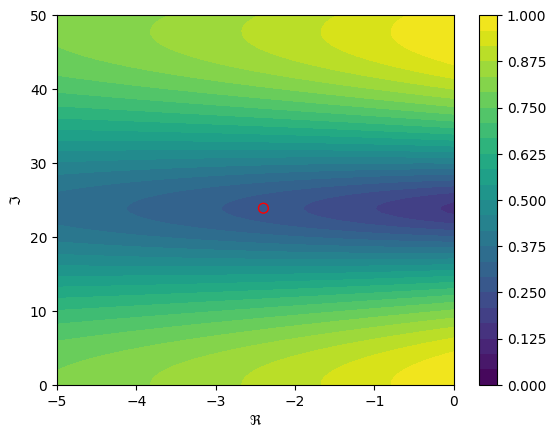

In [31]:
fig, ax = plt.subplots(1,1)
x, y = real_points, imag_points
z = r
c = ax.contourf(x, y, z, levels=np.linspace(0,np.max(z),25))
#fig.suptitle(AA(prefix)+' Input Data Contour Map')
ax.set_xlabel('$\Re$')
ax.set_ylabel('$\Im$')
plt.scatter([np.real(s0)], [np.imag(s0)], s=50, facecolors='none', edgecolors='r', marker="o")
#plt.xticks(np.arange(-180, 181, 30))
#plt.yticks(np.arange(-180, 181, 30))                                

plt.colorbar(c, ax=ax)


In [32]:
def create_eqineq(s0: complex, tau_vector: npt.NDArray, gamma: float=None):
    """Creates equalities and inequalites for shaper problem

    Args:

        gamma (float): gamma, if not specified, assumed gamma is also parameter
            of shaper
    
    
                     1 
    S(s) = gamma +  --- (a0 exp(-s * tau0) + ... + aN exp(-s * tauN))
                     s 
    
    
    """
    # x = [a0, a1, ... , aN, gamma]^T if gamma defined
    # x = [a0, a1, ... , aN]^T if gamma fixed

    na = tau_vector.shape[0] 
    ncols = na + (gamma is None)
    
    # inequalities of form A@x <= b
    Aineq = np.zeros(shape=(na, ncols), dtype=np.float64)
    Aineq[:na, :na] = -np.tril(np.ones(shape=(na,na)), 0)
    bineq = np.zeros(shape=(na,), dtype=np.float64)

    # equalities of form A@x == b
    Aeq = np.zeros(shape=(4, ncols), dtype=np.float64)
    v = 1 / s0 * np.exp(-s0*tau_vector)
    gamma_col = np.array([0, 1, 1, 0], dtype=np.float64)
    Aeq[0,:na] = 1.0 # finite impulse
    Aeq[1,:na] = -tau_vector # static gain is 1.0
    Aeq[2,:na] = np.real(v) # placed pole Re
    Aeq[3,:na] = np.imag(v) # placed pole Im
    beq = np.array([0, 1, 0, 0], dtype=np.float64)
    if gamma:
        beq = beq - gamma_col * gamma
    else:
        Aeq[:, na] = gamma_col
    
    return Aineq, bineq[:, np.newaxis], Aeq, beq[:, np.newaxis]

def create_criterion(s0: complex, tau_vector, **kwargs):
    """ TODO """
    assert np.imag(s0) != 0.0

    n_omega = kwargs.get("n_omega", 20)
    n_zeta = kwargs.get("n_zeta", 20)
    na = tau_vector.shape[0]

    omega_nom = np.abs(s0)
    zeta_nom = -np.real(s0) / omega_nom

    # first, try to obtain minimum or maximum defined via user
    omega_min, omega_max = kwargs.get("omega_lim", (None, None))
    zeta_min, zeta_max = kwargs.get("zeta_lim", (None, None))

    if not(omega_min and omega_max and zeta_min and zeta_max):
        # NOT all limits defined correctly by user
        # -> try to obtain slacks
        omega_slack = kwargs.get("omega_slack", None)
        zeta_slack = kwargs.get("zeta_slack", None)
        # if slacks not defined, just take 10% on each side as robustness
        if omega_slack is None:
            # TODO warning
            omega_slack = 0.1
        if zeta_slack is None:
            # TODO warning
            zeta_slack = 0.1
        
        omega_min = (1 - omega_slack) * omega_nom
        omega_max = (1 + omega_slack) * omega_nom
        zeta_min = (1 - zeta_slack) * zeta_nom
        zeta_max = (1 + zeta_slack) * zeta_nom

    # Create chebyshev grid
    omega_vector = (0.5*(omega_max + omega_min) 
                    - 0.5* (omega_max - omega_min)
                            * np.polynomial.chebyshev.chebpts2(n_omega))
    zeta_vector = (0.5*(zeta_max + zeta_min) 
                    - 0.5* (zeta_max - zeta_min)
                            * np.polynomial.chebyshev.chebpts2(n_zeta))
    
    # s = -omega*zeta + 1j * omega * sqrt(1 - zeta^2)
    complex_grid = (-omega_vector[:,np.newaxis]*zeta_vector[np.newaxis,:] # Re
                    + 1j*omega_vector[:,np.newaxis] *  np.sqrt(1-np.power(zeta_vector[np.newaxis,:],2)))
    
    # create H matrix
    H = np.zeros(shape=(na+1, na+1))
    tau_max = tau_vector[-1] # TODO
    for z in complex_grid.reshape(-1):
        L = np.r_[np.exp(-tau_vector*z)/z, 1.0]
        scalar = np.exp(-2*np.abs(np.real(z))*tau_max)
        H = H + scalar*np.real(np.outer(np.conj(L), L))
    
    H = 1./n_omega/n_zeta * H


    
    # L = np.exp(-tau_vector[:, np.newaxis] * complex_grid.reshape(-1)[np.newaxis, :]) / complex_grid.reshape(-1)
    # Lstar = np.conj(L)[np.newaxis,:,:] # (1,s, ntau)

    # H = np.einsum('mnr,ndr->mdr', L[:,np.newaxis,:], np.conj(L)[np.newaxis,:,:]) # (s, ntau, ntau)
    # H = np.real(H) * np.exp(-2*np.abs(np.real(complex_grid.reshape(-1)))*tau_max)


    # H = np.sum(H, axis=2)

    print(H)
    print(H.shape)

    #print(L)
    

    
    plt.figure()
    plt.scatter(np.real(complex_grid.reshape(-1)), np.imag(complex_grid.reshape(-1)), facecolors='none', edgecolors="b", alpha=0.5, marker="o")
    plt.scatter([np.real(s0)], [np.imag(s0)], s=50, color="r", marker="x")


    # print(complex_grid[0,0])
    
    # print(complex_grid)



    print(f"{s0}, {-omega_nom*zeta_nom + 1j*omega_nom*(1-zeta_nom**2)**0.5}")
    return H

def step_response(gamma, a_vector, tau_vector):
    return tau_vector, np.r_[gamma, gamma + np.cumsum(np.diff(tau_vector) * np.cumsum(a_vector)[:-1])]

def eval_shaper(s, gamma, a_vector, tau_vector):
    return gamma + np.inner(a_vector, np.exp(-s*tau_vector)) / s

[[ 4.28778678e-04  4.14593155e-04  3.40137344e-04  2.11622179e-04
   4.35997764e-05 -1.42558763e-04 -3.21312178e-04 -4.66409619e-04
  -5.54701804e-04 -5.69755272e-04 -5.04713549e-04 -3.63924963e-04
  -1.63011464e-04  7.27321890e-05  3.11473437e-04  5.19134466e-04
   6.64266944e-04  7.22810870e-04  6.82016448e-04  5.42894158e-04
  -1.00323204e-03]
 [ 4.14593155e-04  4.61672624e-04  4.46386952e-04  3.66156800e-04
   2.27680119e-04  4.66498181e-05 -1.53889050e-04 -3.46397922e-04
  -5.02579106e-04 -5.97487854e-04 -6.13430923e-04 -5.43051113e-04
  -3.91079439e-04 -1.74403782e-04  7.96647709e-05  3.36780807e-04
   5.60201041e-04  7.16046288e-04  7.78434620e-04  7.33707006e-04
  -4.76572890e-03]
 [ 3.40137344e-04  4.46386952e-04  4.97118450e-04  4.80646334e-04
   3.94188930e-04  2.44969824e-04  4.99131543e-05 -1.66129477e-04
  -3.73464249e-04 -5.41585218e-04 -6.43611334e-04 -6.60491921e-04
  -5.84332228e-04 -4.20279566e-04 -1.86591338e-04  8.72425849e-05
   3.64163362e-04  6.04551405e-04  7.7

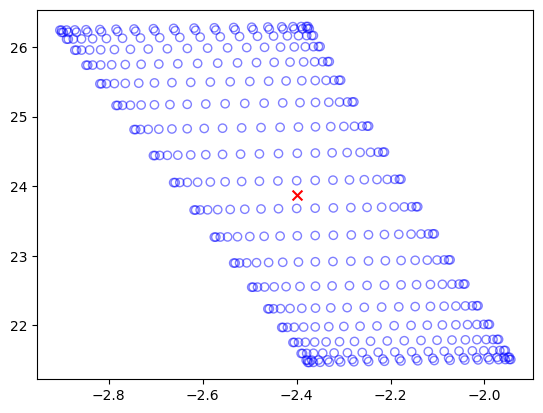

In [33]:
tau_vector = np.linspace(0,0.3,20)
H = create_criterion(s0, tau_vector)
Aineq, bineq, Aeq, beq = create_eqineq(s0, tau_vector)

In [34]:
x = cp.Variable(1+len(tau_vector))
problem = cp.Problem(
    cp.Minimize(cp.quad_form(x, H)),
    constraints=[
        Aineq @ x <= bineq[:,0],
        Aeq @ x == beq[:,0],
    ]
)

In [35]:
problem.solve(verbose=True)
a_vector = x.value[:-1]
gamma = x.value[-1]

                                     CVXPY                                     
                                     v1.5.3                                    
(CVXPY) Sep 02 09:52:31 AM: Your problem has 21 variables, 24 constraints, and 0 parameters.
(CVXPY) Sep 02 09:52:31 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Sep 02 09:52:31 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Sep 02 09:52:31 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Sep 02 09:52:31 AM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Sep 02 09:52:31 AM: Compiling problem (target solver=OSQP).
(CV

In [36]:
# Create chebyshev grid
real_vector = np.linspace(-5, 2, 100)
imag_vector = np.linspace(0.1, 100, 80)
re, im = np.meshgrid(real_vector, imag_vector)
complex_array = re + im*1j

# r = np.abs(
#     np.sum(
#         gamma + np.einsum(
#             'ij,ijk->ijk',
#             1 / complex_array,
#             np.exp(complex_array[:,:,np.newaxis] * tau_vector[np.newaxis,:]) * a_vector,
#         ),
#         axis=-1
#     )
# )
r = np.abs(np.vectorize(lambda s: eval_shaper(s, gamma, a_vector, tau_vector))(complex_array)) * np.exp(np.abs(np.real(complex_array))*tau_vector[-1])

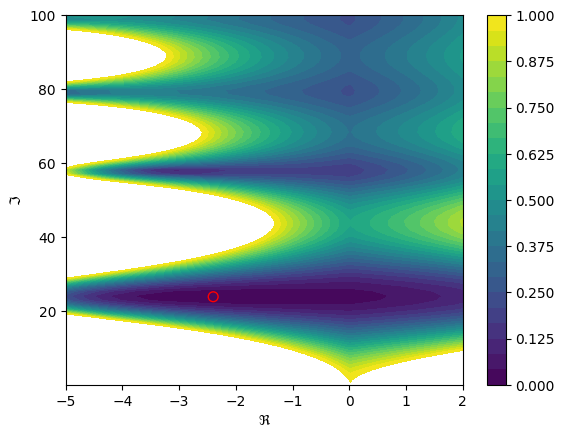

In [37]:
fig, ax = plt.subplots(1,1)
x, y = real_points, imag_points
z = r
c = ax.contourf(re, im, z, levels=np.linspace(0,1.0,25))
#fig.suptitle(AA(prefix)+' Input Data Contour Map')
ax.set_xlabel('$\Re$')
ax.set_ylabel('$\Im$')
plt.scatter([np.real(s0)], [np.imag(s0)], s=50, facecolors='none', edgecolors='r', marker="o")
#plt.xticks(np.arange(-180, 181, 30))
#plt.yticks(np.arange(-180, 181, 30))                                

plt.colorbar(c, ax=ax)

In [38]:
eval_shaper(s0, gamma, a_vector, tau_vector)

(-4.478053853562702e-06-6.517784683643159e-08j)

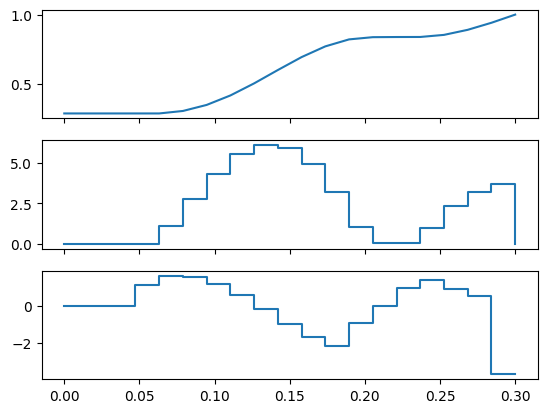

In [39]:
x, y = step_response(gamma, a_vector, tau_vector)
fig, (ax1, ax2, ax3) = plt.subplots(3,1, sharex=True)
ax1.plot(x,y)
ax2.step(tau_vector, np.cumsum(a_vector), where="post")
ax3.step(np.r_[tau_vector, tau_vector[-1]], np.r_[a_vector, a_vector[-1]], where="pre")

In [40]:
def create_problem(T, gamma, s0, N=10, strategy="linspace") -> cp.Problem:
    if strategy == "linspace":
        tau_vector = np.linspace(0,T,N)
    elif strategy == "cheb":        
        tau_vector = (T - T*np.cos(np.linspace(0, np.pi, N)))/2
    else:
        raise NotImplementedError("...")
    F = np.tril(np.ones(shape=(N,N)), 0)
    a = cp.Variable(shape=(N,1))
    v = 1 / s0 * np.exp(-s0*tau_vector)
    constraints = [
        F @ a >= np.zeros(shape=(N,1)),
        cp.sum(a) == 0,
        gamma - tau_vector[np.newaxis,:] @ a == 1,
        #gamma + tau_vector[np.newaxis,:] @ F@a == 1,
        gamma + np.real(v)[np.newaxis,:] @ a == 0,
        np.imag(v)[np.newaxis,:] @ a == 0,
    ]

    objective = cp.Minimize(cp.sum(cp.square(a)))
    problem = cp.Problem(
        objective,
        constraints,
    )
    return problem

In [41]:
N_gamma = 20
N_T = 300
N = 10
gamma_vector = np.linspace(0.001, 0.999, N_gamma)
T_vector = np.linspace(0, 3.0, N_T)

feasibility_matrix = np.ones(shape=(N_T, N_gamma))
for i in range(N_T):
    for j in range(N_gamma):
        print(f"{T_vector[i]=}, {gamma_vector[j]=}")
        prob = create_problem(T_vector[i], gamma_vector[j], s0, N)
        try:
            prob.solve()
        except Exception as e:
            print(e)
            feasibility_matrix[i,j] = -1
        if prob.status == "infeasible":
            print(prob.status)
            feasibility_matrix[i,j] = 0

T_vector[i]=0.0, gamma_vector[j]=0.001
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.053526315789473686
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.10605263157894737
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.15857894736842104
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.21110526315789474
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.26363157894736844
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.3161578947368421
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.3686842105263158
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.4212105263157895
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.4737368421052632
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.5262631578947369
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.5787894736842105
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.6313157894736842
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.6838421052631579
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.7363684210526316
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.7888947368421053
infeasible

c:\Users\apeichl\source\tdspy\.venv\lib\site-packages\cvxpy\problems\problem.py:1407: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


T_vector[i]=2.0869565217391304, gamma_vector[j]=0.3161578947368421
T_vector[i]=2.0869565217391304, gamma_vector[j]=0.3686842105263158
T_vector[i]=2.0869565217391304, gamma_vector[j]=0.4212105263157895
T_vector[i]=2.0869565217391304, gamma_vector[j]=0.4737368421052632
T_vector[i]=2.0869565217391304, gamma_vector[j]=0.5262631578947369
infeasible
T_vector[i]=2.0869565217391304, gamma_vector[j]=0.5787894736842105
infeasible
T_vector[i]=2.0869565217391304, gamma_vector[j]=0.6313157894736842
infeasible
T_vector[i]=2.0869565217391304, gamma_vector[j]=0.6838421052631579
infeasible
T_vector[i]=2.0869565217391304, gamma_vector[j]=0.7363684210526316
infeasible
T_vector[i]=2.0869565217391304, gamma_vector[j]=0.7888947368421053
infeasible
T_vector[i]=2.0869565217391304, gamma_vector[j]=0.841421052631579
infeasible
T_vector[i]=2.0869565217391304, gamma_vector[j]=0.8939473684210526
infeasible
T_vector[i]=2.0869565217391304, gamma_vector[j]=0.9464736842105264
infeasible
T_vector[i]=2.0869565217391304,

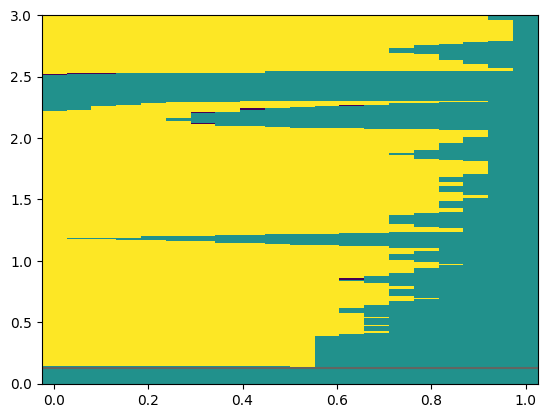

In [42]:
plt.pcolormesh(gamma_vector, T_vector, feasibility_matrix)
plt.axhline(np.pi/np.abs(np.imag(s0)), color="red", alpha=0.3)

In [43]:
for i in range(N_T):
    for j in range(N_gamma):
        print(f"{T_vector[i]=}, {gamma_vector[j]=}")
        prob = create_problem(T_vector[i], gamma_vector[j], s0, N, strategy="cheb")

        
        try:
            prob.solve()
        except Exception as e:
            print(e)
            feasibility_matrix[i,j] = -1
        if prob.status == "infeasible":
            print(prob.status)
            feasibility_matrix[i,j] = 0

T_vector[i]=0.0, gamma_vector[j]=0.001
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.053526315789473686
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.10605263157894737
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.15857894736842104
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.21110526315789474
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.26363157894736844
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.3161578947368421
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.3686842105263158
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.4212105263157895
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.4737368421052632
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.5262631578947369
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.5787894736842105
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.6313157894736842
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.6838421052631579
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.7363684210526316
infeasible
T_vector[i]=0.0, gamma_vector[j]=0.7888947368421053
infeasible

c:\Users\apeichl\source\tdspy\.venv\lib\site-packages\cvxpy\problems\problem.py:1407: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


infeasible
T_vector[i]=0.8829431438127091, gamma_vector[j]=0.6838421052631579
infeasible
T_vector[i]=0.8829431438127091, gamma_vector[j]=0.7363684210526316
infeasible
T_vector[i]=0.8829431438127091, gamma_vector[j]=0.7888947368421053
infeasible
T_vector[i]=0.8829431438127091, gamma_vector[j]=0.841421052631579
infeasible
T_vector[i]=0.8829431438127091, gamma_vector[j]=0.8939473684210526
infeasible
T_vector[i]=0.8829431438127091, gamma_vector[j]=0.9464736842105264
infeasible
T_vector[i]=0.8829431438127091, gamma_vector[j]=0.999
infeasible
T_vector[i]=0.8929765886287626, gamma_vector[j]=0.001
T_vector[i]=0.8929765886287626, gamma_vector[j]=0.053526315789473686
T_vector[i]=0.8929765886287626, gamma_vector[j]=0.10605263157894737
T_vector[i]=0.8929765886287626, gamma_vector[j]=0.15857894736842104
T_vector[i]=0.8929765886287626, gamma_vector[j]=0.21110526315789474
T_vector[i]=0.8929765886287626, gamma_vector[j]=0.26363157894736844
T_vector[i]=0.8929765886287626, gamma_vector[j]=0.316157894736

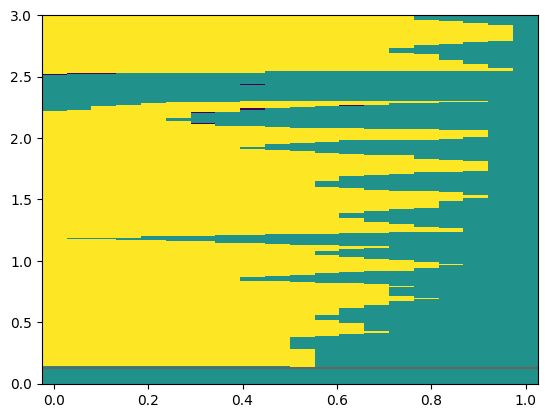

In [44]:
plt.pcolormesh(gamma_vector, T_vector, feasibility_matrix)
plt.axhline(np.pi/np.abs(np.imag(s0)), color="red", alpha=0.3)

In [77]:
def create_problem(s0, T, N, objective="min") -> cp.Problem:
    gamma = cp.Variable(1, nonneg=True)
    constraints = [
        gamma <= 1.0
    ]
    tau_vector = np.linspace(0, T, N)
    F = np.tril(np.ones(shape=(N,N)), 0)
    a = cp.Variable(shape=(N,1))
    v = 1 / s0 * np.exp(-s0*tau_vector)
    constraints.extend(
        [
            F @ a >= np.zeros(shape=(N,1)),
            cp.sum(a) == 0,
            gamma - tau_vector[np.newaxis,:] @ a == 1,
            gamma + np.real(v)[np.newaxis,:] @ a == 0,
            np.imag(v)[np.newaxis,:] @ a == 0,
        ]
    )
    if objective == "min":
        objective = cp.Minimize(gamma)
    else:
        objective = cp.Maximize(gamma)
    problem = cp.Problem(
        objective,
        constraints,
    )
    return problem

Tmax = 10*np.pi / np.abs(np.imag(s0))
dT = 0.01
Nmax = 20
solver = "CLARABEL"

Trange = np.arange(dT, Tmax, dT)
Nrange = np.arange(2, Nmax+1)
lb_matrix = np.full(shape=(len(Nrange), len(Trange)), fill_value=np.nan, dtype=np.float64)
ub_matrix = np.full(shape=(len(Nrange), len(Trange)), fill_value=np.nan, dtype=np.float64)
lb_solver_failed = np.full(shape=(len(Nrange), len(Trange)), fill_value=False, dtype=np.float64)
ub_solver_failed = np.full(shape=(len(Nrange), len(Trange)), fill_value=False, dtype=np.float64)

for i, N in enumerate(Nrange):
    for j, T in enumerate(Trange):
        problem_lb = create_problem(s0, T, N, "min")
        problem_ub = create_problem(s0, T, N, "max")

        try:
            problem_lb.solve(solver=solver)
            if problem_lb.status == "infeasible":
                pass
            else:
                lb_matrix[i,j] = problem_lb.objective.value
        except Exception as e:
            print(e)
            lb_solver_failed[i,j] = True
        
        try:
            problem_ub.solve(solver=solver)
            if problem_ub.status == "infeasible":
                pass
            else:
                ub_matrix[i,j] = problem_ub.objective.value
        except Exception as e:
            print(e)
            ub_solver_failed[i,j] = True


c:\Users\apeichl\source\tdspy\.venv\lib\site-packages\cvxpy\reductions\solvers\solving_chain.py:356: FutureWarning: 
    You specified your problem should be solved by ECOS. Starting in
    CXVPY 1.6.0, ECOS will no longer be installed by default with CVXPY.
    Please either add ECOS as an explicit install dependency to your project
    or switch to our new default solver, Clarabel, by either not specifying a
    solver argument or specifying ``solver=cp.CLARABEL``. To suppress this
    warning while continuing to use ECOS, you can filter this warning using
    Python's ``warnings`` module until you are using 1.6.0.
    
  warnings.warn(ECOS_DEP_DEPRECATION_MSG, FutureWarning)


Solver 'ECOS' failed. Try another solver, or solve with verbose=True for more information.
Solver 'ECOS' failed. Try another solver, or solve with verbose=True for more information.
Solver 'ECOS' failed. Try another solver, or solve with verbose=True for more information.
Solver 'ECOS' failed. Try another solver, or solve with verbose=True for more information.
Solver 'ECOS' failed. Try another solver, or solve with verbose=True for more information.
Solver 'ECOS' failed. Try another solver, or solve with verbose=True for more information.
Solver 'ECOS' failed. Try another solver, or solve with verbose=True for more information.
Solver 'ECOS' failed. Try another solver, or solve with verbose=True for more information.
Solver 'ECOS' failed. Try another solver, or solve with verbose=True for more information.
Solver 'ECOS' failed. Try another solver, or solve with verbose=True for more information.
Solver 'ECOS' failed. Try another solver, or solve with verbose=True for more information.

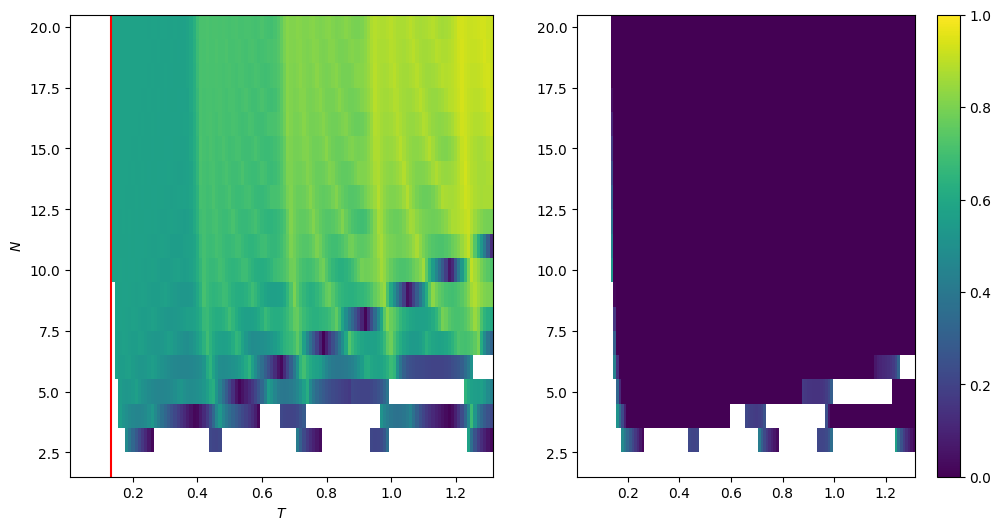

In [76]:

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
x,y = np.meshgrid(Trange, Nrange)

c1 = ax1.pcolormesh(x, y, lb_matrix, vmin=0, vmax=1)
ax1.axvline(np.pi/np.abs(np.imag(s0)), color="red")
#fig.suptitle(AA(prefix)+' Input Data Contour Map')
ax1.set_xlabel('$T$')
ax1.set_ylabel('$N$')
#plt.colorbar(c1, ax=ax1)

c2 = ax2.pcolormesh(x, y, ub_matrix, vmin=0, vmax=1)
#c2 = ax2.contourf(x, y, ub_matrix, levels=np.linspace(0,1.0,25))

plt.colorbar(c2, ax=ax2)
#fig.suptitle(AA(prefix)+' Input Data Contour Map')



#plt.scatter([np.real(s0)], [np.imag(s0)], s=50, facecolors='none', edgecolors='r', marker="o")
#plt.xticks(np.arange(-180, 181, 30))
#plt.yticks(np.arange(-180, 181, 30))                                


In [71]:
Nrange

array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20])